# Compressible Euler Equations - GP-Bayes OpInf (Baseline)

This notebook demonstrates the baseline GP-Bayes Operator Inference method for the compressible Euler equations.

In [1]:
# Setup paths and imports
import sys
import os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), '..'))

import numpy as np
import random
import matplotlib.pyplot as plt

import opinf

# Import from core and local config
from core import (
    summarize_experiment,
    generate_trajectory,
    fit_gaussian_processes,
    save_paper_figure,
)
import config
import step3_estimate as step3

/home/anthonypoole/miniconda3/envs/prob-rom-inf/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Configuration
RANDOM_SEED = 42
training_span = (0, 0.08)
num_samples = 55
noiselevel = 0.05
num_regression_points = 150
numPODmodes = 6
gp_regularizer = 1e-6
ndraws = 100
VERBOSE = True

# Paper figure generation
SAVE_PAPER_FIGURES = False         # Set True to save publication figures
PAPER_SCENARIO = "dense_low"      # Scenario tag: dense_low, dense_high, sparse_med, etc.
PAPER_FIGURES_DIR = "../../GP-Bayes-Refactor/figures/manu"


In [ ]:
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

if isinstance(numPODmodes, (list, tuple)) and len(numPODmodes) == 1:
    numPODmodes = numPODmodes[0]

# Report experimental scenario
summarize_experiment(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    numPODmodes=numPODmodes,
    gp_regularizer=gp_regularizer,
    ndraws=ndraws,
    figures_path="figures",
)

# Generate training data
(
    model,
    time_domain,
    true_states,
    time_domain_sampled,
    snapshots_sampled,
) = generate_trajectory(config, config.time_domain, training_span, num_samples, noiselevel)

time_domain_eval_training = np.linspace(0, max(time_domain_sampled), num_regression_points)
time_domain_eval_prediction = np.linspace(0, max(time_domain), int(num_regression_points/max(time_domain_sampled) * max(time_domain)))

print(f"Data shapes: true_states={true_states.shape}, snapshots={snapshots_sampled.shape}")


reducing noisy training states to 6 dimensions...done in 0.03 s.

fitting GP model for state 'r_01'...
Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 2.6224e-01
	\ell = 3.9182e-03
	\chi = 5.3228e-04
done in 2.88 s.
computing weight matrix...done in 0.04 s.

fitting GP model for state 'r_02'...
Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 3.2678e-01
	\ell = 4.1146e-03
	\chi = 4.2421e-04
done in 2.33 s.
computing weight matrix...done in 0.05 s.

fitting GP model for state 'r_03'...
Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 7.2499e-02
	\ell = 4.2346e-03
	\chi = 2.5657e-04
done in 2.90 s.
computing weight matrix...done in 0.04 s.

fitting GP model for state 'r_04'...
Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 1.0008e-01
	\ell = 3.2

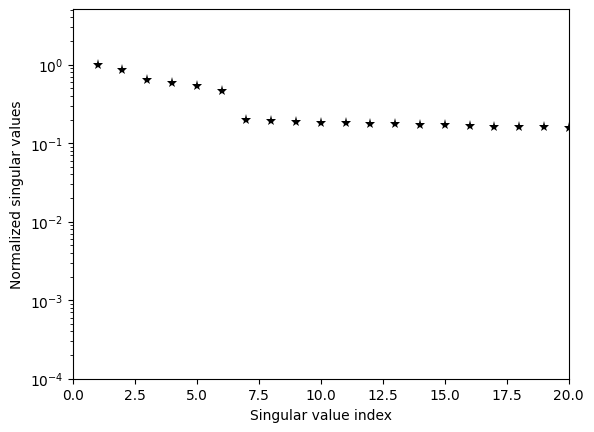

In [3]:
import time
start_time = time.time()

# Dimensionality reduction (POD)
with opinf.utils.TimedBlock(f"reducing noisy training states to {numPODmodes} dimensions"):
    basis = config.Basis(num_vectors=numPODmodes)
    basis.fit(snapshots_sampled)
    ax = basis.plot_svdval_decay()
    ax.set_xlim(right=20)
    ax.set_ylim(bottom=1e-4)
    snapshots_compressed = basis.compress(snapshots_sampled)
    true_states_compressed = basis.compress(true_states)

# Fit Gaussian process kernels to the compressed training data
time_domain_training = np.linspace(
    training_span[0],
    training_span[-1],
    num_regression_points,
)

gps = fit_gaussian_processes(
    time_domain_training=time_domain_training,
    time_domain_sampled=time_domain_sampled,
    snapshots_sampled=snapshots_compressed,
    gp_regularizer=gp_regularizer,
    constant_bounds=config.CONSTANT_VALUE_BOUNDS,
    length_scale_bounds=config.LENGTH_SCALE_BOUNDS,
    noise_level_bounds=config.NOISE_LEVEL_BOUNDS,
    n_restarts_optimizer=config.N_RESTARTS_OPTIMIZER,
)

q0 = snapshots_compressed[:, 0]

In [4]:
# Create the posterior and fit it 
input_func = config.ReducedOrderModel.input_func
inputs = None if input_func is None else input_func(time_domain_training)
bayesian_model = step3.estimate_posterior(
    time_domain=time_domain,
    gps=gps,
    inputs=inputs,
)

constructing posterior hyperparameters...

GRIDSEARCH
(1/81) Testing regularizer 1.0000e-16...UNSTABLE
(2/81) Testing regularizer 1.7783e-16...UNSTABLE
(3/81) Testing regularizer 3.1623e-16...UNSTABLE
(4/81) Testing regularizer 5.6234e-16...UNSTABLE
(5/81) Testing regularizer 1.0000e-15...UNSTABLE
(6/81) Testing regularizer 1.7783e-15...UNSTABLE
(7/81) Testing regularizer 3.1623e-15...UNSTABLE
(8/81) Testing regularizer 5.6234e-15...UNSTABLE
(9/81) Testing regularizer 1.0000e-14...UNSTABLE
(10/81) Testing regularizer 1.7783e-14...UNSTABLE
(11/81) Testing regularizer 3.1623e-14...UNSTABLE
(12/81) Testing regularizer 5.6234e-14...UNSTABLE
(13/81) Testing regularizer 1.0000e-13...UNSTABLE
(14/81) Testing regularizer 1.7783e-13...UNSTABLE
(15/81) Testing regularizer 3.1623e-13...UNSTABLE
(16/81) Testing regularizer 5.6234e-13...UNSTABLE
(17/81) Testing regularizer 1.0000e-12...UNSTABLE
(18/81) Testing regularizer 1.7783e-12...UNSTABLE
(19/81) Testing regularizer 3.1623e-12...UNSTABLE
(20/8

In [5]:
# Draw samples from the posterior.
with opinf.utils.TimedBlock("sampling posterior distribution"):
    draws_compressed_training = []
    draws_compressed = []
    qbar = snapshots_compressed.mean(axis=1).reshape((-1, 1))
    bound = 5 * np.max(np.abs(snapshots_compressed - qbar), axis=1)
    num_unstables = 0
    Os = []
    for _ in range(ndraws):
        draw = bayesian_model.predict(
            initial_conditions=q0,
            timepoints=time_domain,
            input_func=input_func,
        )
        training_draw = bayesian_model.predict(
            initial_conditions=q0,
            timepoints=time_domain_eval_training,
            input_func=input_func,
        )
        Os.append(bayesian_model.rvs())
        if draw.shape[1] != time_domain.size or training_draw.shape[1] != time_domain_training.size:
            num_unstables += 1
            continue
        if np.any(np.abs(draw - qbar).max(axis=1) > bound):
            num_unstables += 1
            continue
        draws_compressed_training.append(training_draw)
        draws_compressed.append(draw)
    if num_unstables:
        print(f"\n{num_unstables}/{ndraws} draws unstable")

    # Translate results back to original state space.
    draws = [basis.decompress(draw) for draw in draws_compressed]
    Os = np.array(Os)

algo_time = time.time() - start_time
print(f"\nAlgorithm runtime: {algo_time:.1f}s ({algo_time/60:.1f}min)")


sampling posterior distribution...
8/100 draws unstable
done in 1.76 s.


(6, 1) (6, 1) (6, 1)
Number of samples: 1


<Figure size 640x480 with 0 Axes>

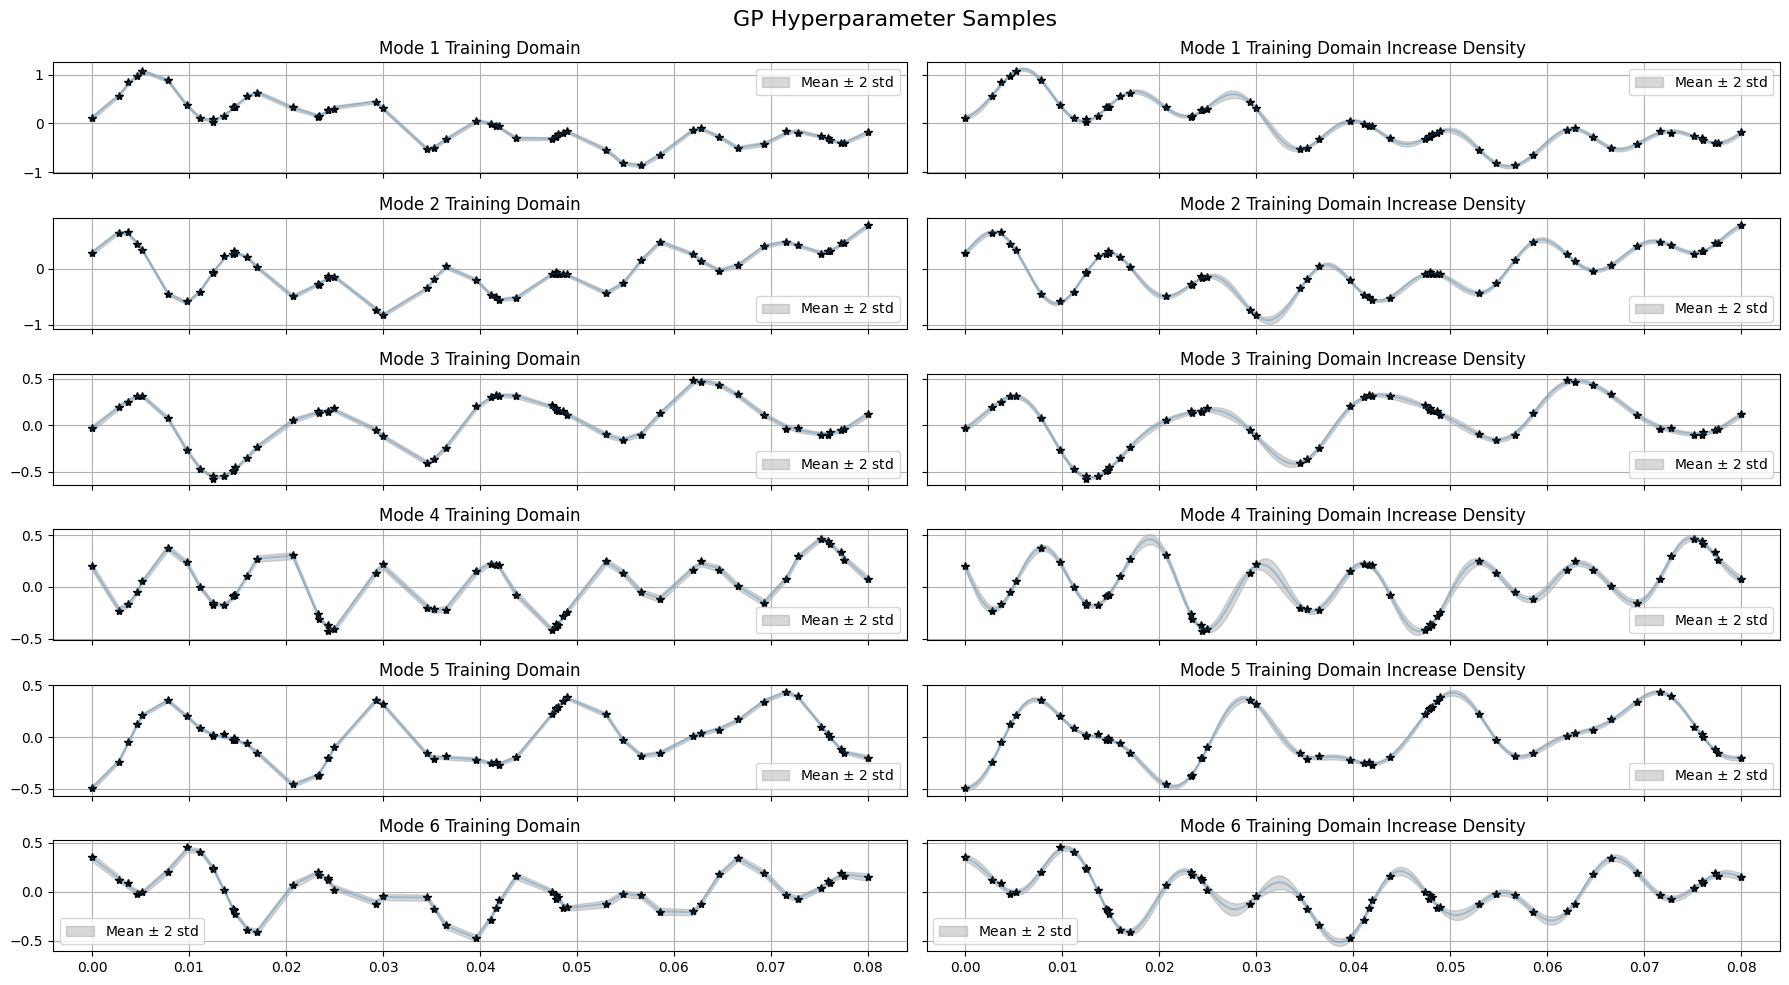

In [8]:
# Plot posterior samples
import euler_plotter
import importlib
importlib.reload(euler_plotter)

time_domain_eval_training = np.linspace(0, max(time_domain_sampled), num_regression_points)
time_domain_eval_prediction = np.linspace(0, max(time_domain), int(num_regression_points/max(time_domain_sampled) * max(time_domain)))

lengthscales = np.array([gps[i].gpr.kernel_.k1.k2.length_scale for i in range(numPODmodes)])[:, None]
variances = np.array([gps[i].gpr.kernel_.k1.k1.constant_value for i in range(numPODmodes)])[:, None]
noises = np.array([gps[i].gpr.kernel_.k2.noise_level for i in range(numPODmodes)])[:, None]

print(lengthscales.shape, variances.shape, noises.shape)

plotter = euler_plotter.EulerPlotter(
            numPODmodes=numPODmodes,
            time_domain_training=time_domain_sampled, 
            time_domain_prediction=time_domain, 
            time_domain_eval_training=time_domain_eval_training,
            time_domain_eval_prediction=time_domain_eval_prediction,
            snapshots_training=snapshots_compressed, 
            snapshots_prediction=true_states_compressed,
            )

plotter.gp_plot_state(
    lengthscales=lengthscales,
    variances=variances,
    noises=noises,
    max_num_samples=250,
    figsize=(18,10)
)


<Figure size 640x480 with 0 Axes>

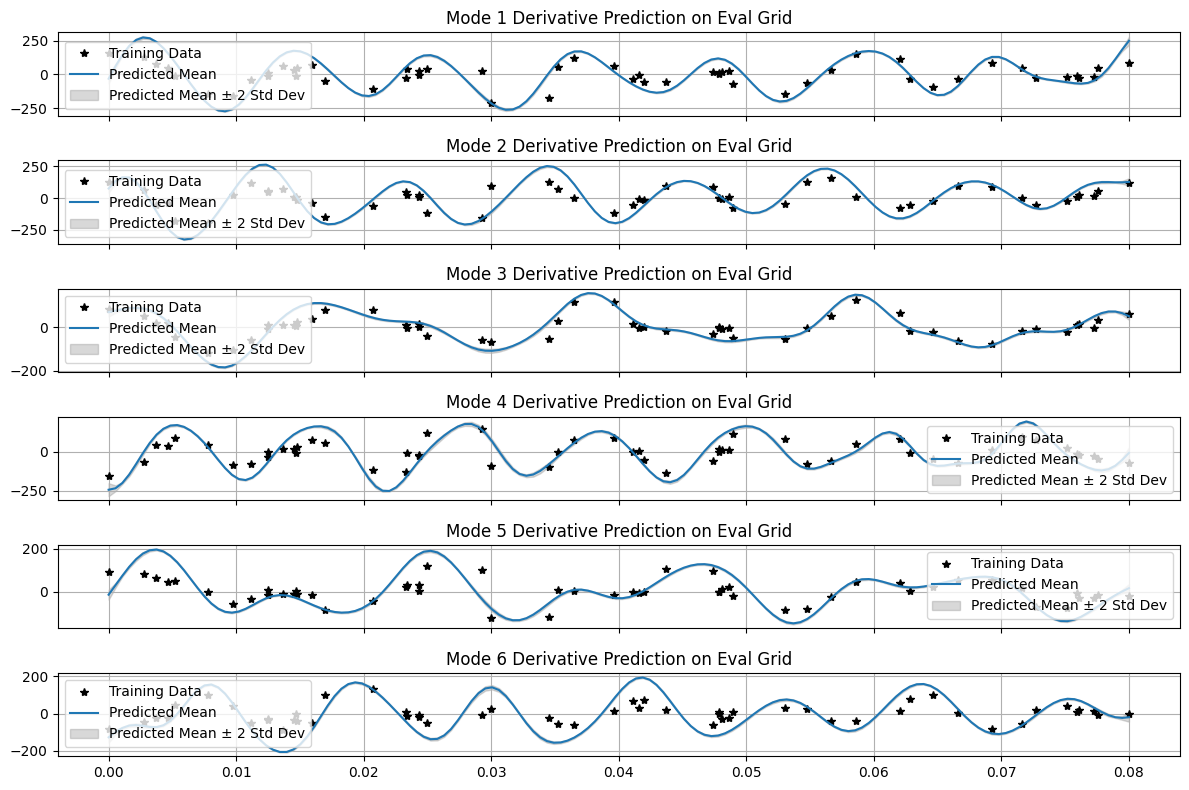

In [9]:

plotter.gp_plot_derivatives()

In [10]:
# Plot ROM predictions — single-column layout matching Full Bayesian style
draws_pred = np.array(draws_compressed)  # (n_stable, modes, time)
draws_train = np.array(draws_compressed_training)  # (n_stable, modes, time)
n_stable = len(draws_pred)

fig, ax = plt.subplots(numPODmodes, 1, figsize=(10, 2.5 * numPODmodes), sharex=True)
if numPODmodes == 1:
    ax = [ax]

for i in range(numPODmodes):
    # Training span shading
    ax[i].axvspan(training_span[0], training_span[1], color='gray', alpha=0.10, zorder=0)

    # True solution
    ax[i].plot(time_domain, true_states_compressed[i],
               color='tab:gray', lw=2, label='True solution')

    # Training data
    ax[i].plot(time_domain_sampled, snapshots_compressed[i],
               'k*', ms=5, label='Training data', zorder=5)

    # ROM median
    if n_stable > 0:
        ax[i].plot(time_domain, np.median(draws_pred[:, i, :], axis=0),
                   color='tab:purple', linestyle='--', alpha=0.9, lw=2, label='ROM median')
        ax[i].fill_between(
            time_domain,
            np.percentile(draws_pred[:, i, :], 5, axis=0),
            np.percentile(draws_pred[:, i, :], 95, axis=0),
            color='tab:purple', alpha=0.15, label='ROM 5\u201395%')

    ax[i].set_ylabel(f'Mode {i+1}')
    if i == 0:
        ax[i].legend(loc='upper right', fontsize=9)

ax[-1].set_xlabel('Time')
fig.suptitle(f'GP-Bayes OpInf: ROM Predictions ({n_stable}/{ndraws} stable)', fontsize=14)
fig.tight_layout()
if SAVE_PAPER_FIGURES:
    save_paper_figure(fig, f"euler_{PAPER_SCENARIO}_gpbo", PAPER_FIGURES_DIR)
plt.show()
